In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/creditcard.csv')
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.173 %


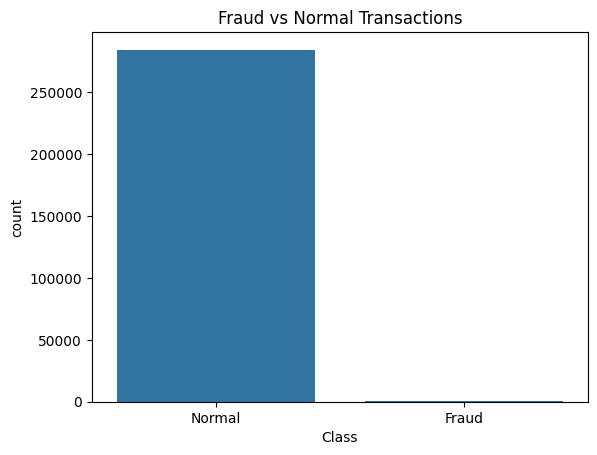

In [6]:
print(df['Class'].value_counts())
print("\nFraud %:", round(df['Class'].mean() * 100, 3), "%")

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()

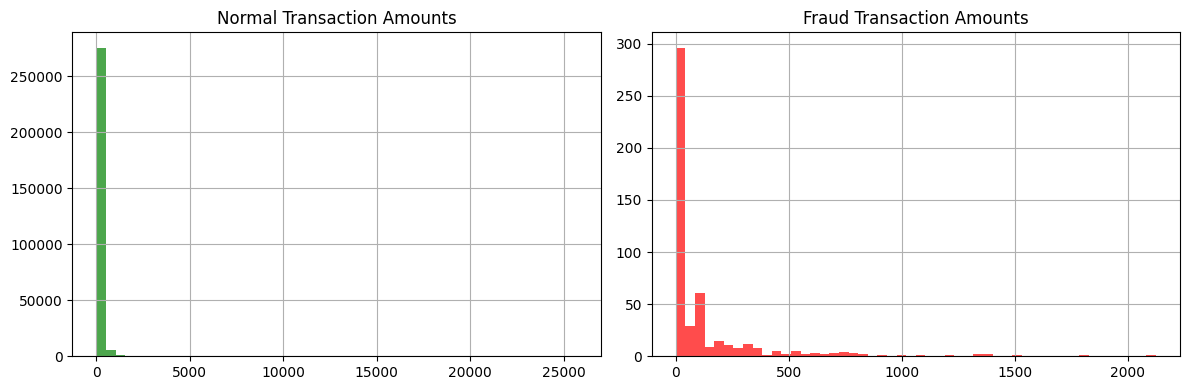

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df[df['Class']==0]['Amount'].hist(ax=axes[0], bins=50, color='green', alpha=0.7)
axes[0].set_title("Normal Transaction Amounts")

df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, color='red', alpha=0.7)
axes[1].set_title("Fraud Transaction Amounts")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale the 'Amount' column (Time is not useful, drop it)
df['NormalizedAmount'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(['Time', 'Amount'], axis=1)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFraud cases:", y.sum())
print("Normal cases:", (y == 0).sum())

Features shape: (284807, 29)
Target shape: (284807,)

Fraud cases: 492
Normal cases: 284315


In [9]:
from imblearn.over_sampling import SMOTE

# Step 1: Split FIRST, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print("Training fraud cases:", y_train.sum())
print("Training normal cases:", (y_train == 0).sum())

# Step 2: Apply SMOTE on training data ONLY
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training fraud cases:", y_train_res.sum())
print("Training normal cases:", (y_train_res == 0).sum())
print("Total training samples:", len(X_train_res))

Before SMOTE:
Training fraud cases: 394
Training normal cases: 227451

After SMOTE:
Training fraud cases: 227451
Training normal cases: 227451
Total training samples: 454902


In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Train the model
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)
print("✅ Model trained successfully!")

# Predict
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Results
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

print("🎯 ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

✅ Model trained successfully!

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962

🎯 ROC-AUC Score: 0.9739


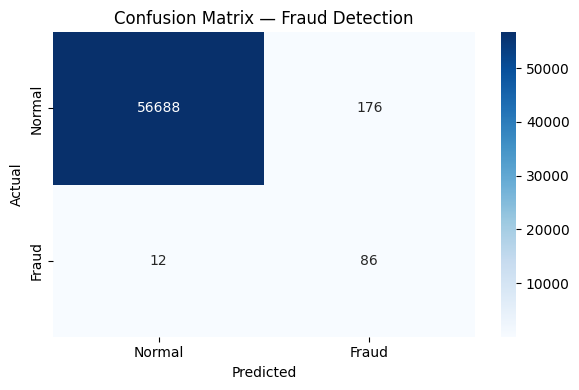

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

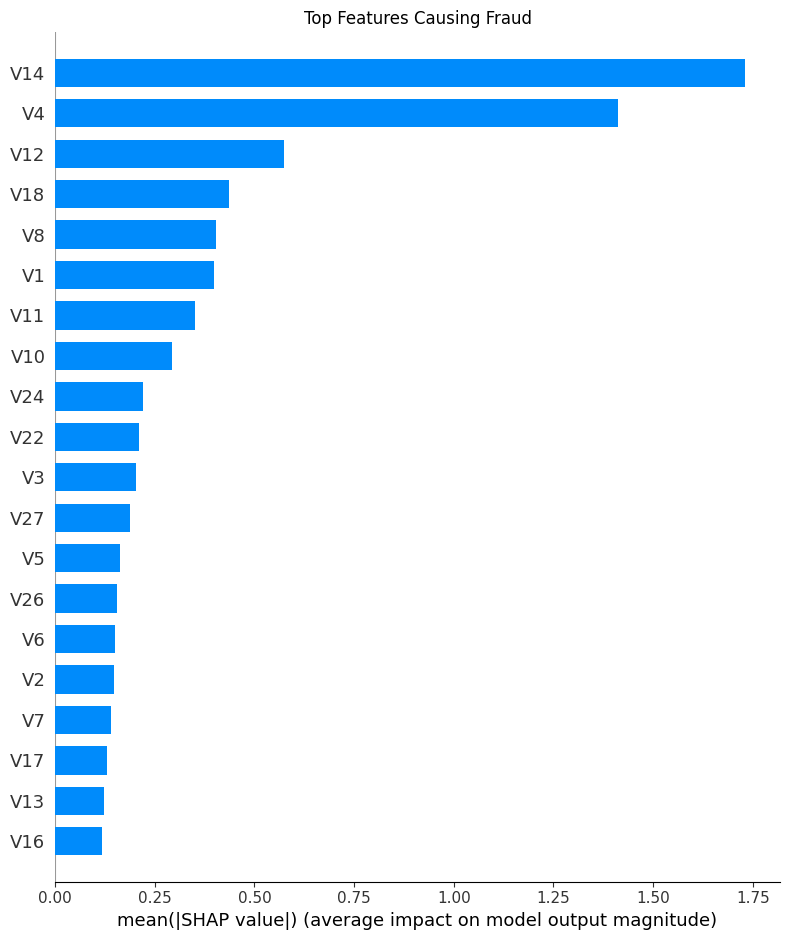

In [12]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Use sample of test data (full dataset takes too long)
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

# Plot 1: Which features matter most overall?
plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", 
                  show=False)
plt.title("Top Features Causing Fraud")
plt.tight_layout()
plt.show()

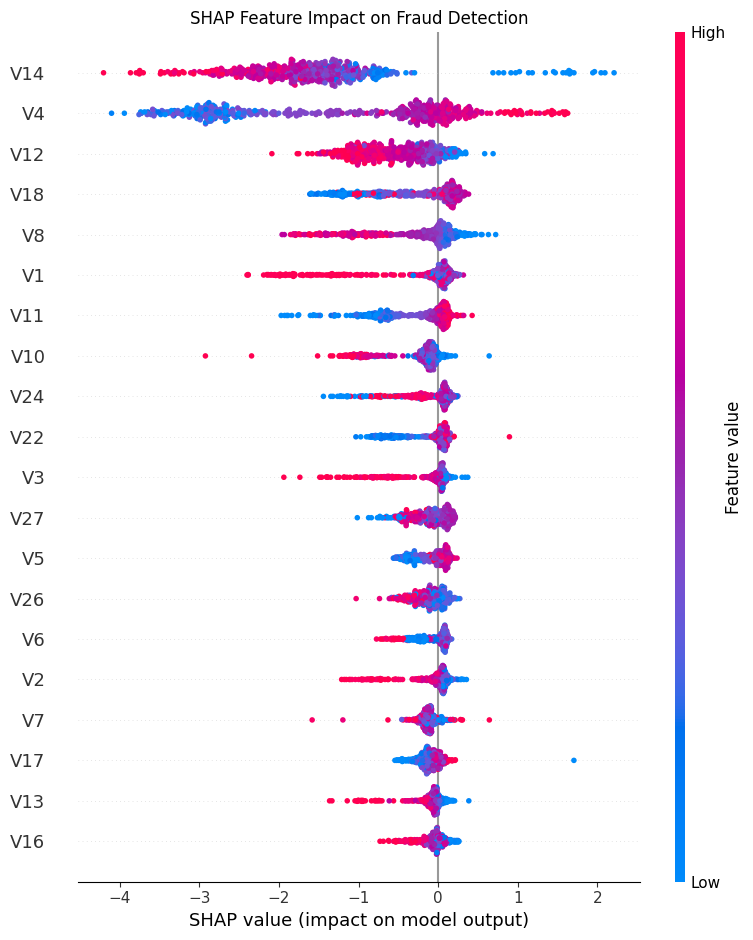

In [13]:
# Plot 2: Detailed impact of each feature
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Feature Impact on Fraud Detection")
plt.tight_layout()
plt.show()

In [14]:
import joblib

# Save model to disk
joblib.dump(model, 'fraud_model.pkl')
print("✅ Fraud model saved as fraud_model.pkl")

# Test loading it back
loaded_model = joblib.load('fraud_model.pkl')
print("✅ Model loaded back successfully!")
print("Test prediction:", loaded_model.predict(X_test.iloc[:1]))

✅ Fraud model saved as fraud_model.pkl
✅ Model loaded back successfully!
Test prediction: [0]
